# Variational Autoencoder (VAE) on MNIST

A **VAE** is a probabilistic variant of the autoencoder. Instead of encoding an input into a single fixed latent vector, the encoder outputs the parameters (mean `mu` and log-variance `logvar`) of a Gaussian distribution over the latent space. A latent vector `z` is then sampled from that distribution (via the **reparameterization trick**, to keep sampling differentiable) and passed to the decoder for reconstruction.

Training optimizes two terms jointly:
- **Reconstruction loss**: how well the decoded output matches the input
- **KL divergence**: keeps the learned latent distribution close to a standard normal, giving the latent space a smooth, continuous structure useful for generation

Here we build a simple fully-connected VAE for MNIST digits with a 20-dimensional latent space.

In [21]:
import os

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = os.path.join("..", "data")

In [22]:
# Check if MPS is available
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


In [23]:
#hyperparams
num_epochs = 100
batch_size = 128
lr = 1e-3

In [24]:
def to_img(x):
    x = 0.5*(x+1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

img_transform = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

In [ ]:
# dataset (MNIST) - reuses DATA_DIR if already downloaded, otherwise fetches it there
dataset = MNIST(DATA_DIR, transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size, shuffle=True)

## Model

Encoder: `784 → 400 → (mu: 20, logvar: 20)`. A latent sample `z` is drawn via reparameterization, then decoded: `20 → 400 → 784` with a final `Sigmoid` to output pixel probabilities in `[0, 1]`.

In [26]:
if not os.path.exists('./vae_img'):
    os.mkdir('./vae_img')

In [27]:
# Model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)   # average
        self.fc22 = nn.Linear(400, 20)   # standard deviation
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparametrize(self, mu, logvar):
        std = logvar.mul(0.5).exp_()
        eps = torch.FloatTensor(std.size()).normal_().to(device)

        return eps.mul(std).add_(mu)
    
    def decode(self, x):
        h3 = F.relu(self.fc3(x))
        return F.sigmoid(self.fc4(h3))

    def forward(self, x):
        # learning average and standard deviation with encoder
        mu, logvar = self.encode(x)

        # reparametrization
        z = self.reparametrize(mu, logvar)

        # decode
        return self.decode(z), mu, logvar

In [28]:
# Instance of the model
model = VAE().to(device)

# loss
reconstraction_loss = nn.MSELoss(size_average=False)

# KL
def loss_function(recon_x, x, mu, logvar):
    recon_loss = reconstraction_loss(recon_x, x)

    kl_element = mu.pow(2).add_(logvar.exp()).mul_(-1).add_(1).add_(logvar)
    kl = torch.sum(kl_element).mul_(-0.5)

    return recon_loss + kl


#optimizer
optimizer = optim.Adam(model.parameters(), lr)

## Training

Flatten each image, run it through the VAE, and minimize reconstruction loss + KL divergence. Every 10 epochs a sample reconstruction is saved to `./vae_img/`.

In [29]:
# Training
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch_idx, data in enumerate(dataloader):
        img, _ = data
        img = img.view(img.size(0), -1).to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(img)
        loss = loss_function(recon_batch, img, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 10 == 0:
            print("Train Epoch: {} [{}/{}] ({:.0f}%]\tLoss: {:.6f}".format(
                epoch,
                batch_idx * len(img),
                len(dataloader.dataset), 100. * batch_idx / len(dataloader), 
                loss.item() / len(img)
            ))

    print("====> Epoch: {} Average Loss: {:.4f}".format(
        epoch, train_loss / len(dataloader.dataset) 
    ))

    if epoch % 10 == 0:
        save = to_img(recon_batch.cpu().data)
        save_image(save, './vae_img/image_{}.png'.format(epoch))

torch.save(model.state_dict(), './vae.pth')

Train Epoch: 0 [0/60000] (0%]	Loss: 183.059540
Train Epoch: 0 [1280/60000] (2%]	Loss: 83.455505
Train Epoch: 0 [2560/60000] (4%]	Loss: 58.718384
Train Epoch: 0 [3840/60000] (6%]	Loss: 56.576950
Train Epoch: 0 [5120/60000] (9%]	Loss: 56.441383
Train Epoch: 0 [6400/60000] (11%]	Loss: 52.131573
Train Epoch: 0 [7680/60000] (13%]	Loss: 53.110558
Train Epoch: 0 [8960/60000] (15%]	Loss: 50.828278
Train Epoch: 0 [10240/60000] (17%]	Loss: 49.386162
Train Epoch: 0 [11520/60000] (19%]	Loss: 49.366154
Train Epoch: 0 [12800/60000] (21%]	Loss: 49.186241
Train Epoch: 0 [14080/60000] (23%]	Loss: 49.197865
Train Epoch: 0 [15360/60000] (26%]	Loss: 44.063042
Train Epoch: 0 [16640/60000] (28%]	Loss: 45.266541
Train Epoch: 0 [17920/60000] (30%]	Loss: 45.616360
Train Epoch: 0 [19200/60000] (32%]	Loss: 44.633804
Train Epoch: 0 [20480/60000] (34%]	Loss: 43.051933
Train Epoch: 0 [21760/60000] (36%]	Loss: 44.447536
Train Epoch: 0 [23040/60000] (38%]	Loss: 41.737427
Train Epoch: 0 [24320/60000] (41%]	Loss: 43.13

## Evaluation

Run the trained VAE on the test set and visually compare original vs. reconstructed digits.

In [ ]:
# test dataset
test_data = MNIST(DATA_DIR, transform=img_transform, download=True, train=False)
test_dataloader = DataLoader(test_data, batch_size, shuffle=False)

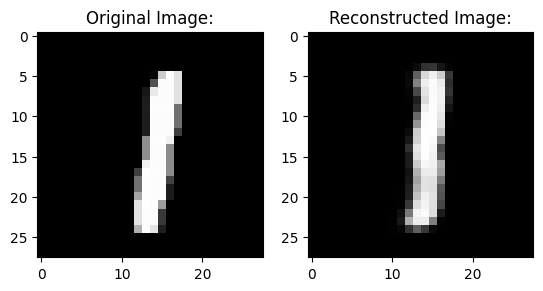

In [33]:
model.eval()
with torch.no_grad():
    for data in test_dataloader:
        img, _ = data
        img_flat = img.view(img.size(0), -1)
        img_flat = img_flat.to(device)

        output, mu, logvar = model(img_flat)
        output = output.detach()

        plt.subplot(1, 2, 1)
        plt.imshow(to_img(img.cpu())[0][0], cmap='gray')
        plt.title("Original Image:")
        plt.subplot(1, 2, 2)
        plt.imshow(to_img(output.cpu())[0][0], cmap='gray')
        plt.title("Reconstructed Image:")